Task 2, Machine Learning with Matrix Data for Recommender Systems
1. Recommender systems are a hot topic. Recommendation systems can be formulated as a
task of matrix completion in machine learning. Recommender systems aim to predict the
rating that a user will give for an item (e.g., a restaurant, a movie, a product).  
2. Download the movie rating dataset from: https://www.kaggle.com/rounakbanik/the
movies-dataset. These files contain metadata for all 45,000 movies listed in the Full
MovieLens Dataset. The dataset consists of movies released on or before July 2017. Data
points include cast, crew, plot keywords, budget, revenue, posters, release dates, languages,
production companies, countries, TMDB vote counts and vote averages. This dataset also
has files containing 26 million ratings from 270,000 users for all 45,000 movies. Ratings are
on a scale of 1-5 and have been obtained from the official GroupLens website.  
3. Building a small recommender system with the matrix data: “ratings small.csv”. You can
use the recommender system library:  Surprise (http://surpriselib.com), use other
recommender system libraries, or implement from scratches.  
a. Read data from “ratings small.csv” with line format: 'userID movieID rating
timestamp'.  
b. MAE and RMSE are two famous metrics for evaluating the performances of a
recommender system. The definition of MAE can be found via:
https://en.wikipedia.org/wiki/Mean_absolute_error. The definition of RMSE can
be found via: https://en.wikipedia.org/wiki/Root-mean-square_deviation.  
c. Compute the average MAE and RMSE of the Probabilistic Matrix Factorization
(PMF), User based Collaborative Filtering, Item based Collaborative Filtering,
under the 5-folds cross-validation (10 points)

In [2]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2555151 sha256=d12a456d350ed4bf15e7be4b416b07f02460fc7d87c66fec197359a58e4b457a
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [7]:
!pip install "numpy<2" scikit-surprise==1.1.4


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python

c. Compute the average MAE and RMSE of the Probabilistic Matrix Factorization
(PMF), User based Collaborative Filtering, Item based Collaborative Filtering,
under the 5-folds cross-validation (10 points)

In [3]:
from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate
import pandas as pd

#Loading the ratings dataset (ratings_small.csv)

df = pd.read_csv("ratings_small.csv")

reader = Reader(rating_scale=(0.5, 5.0))
# rating range from the dataset
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

# Defining the three algorithms

# PMF (Probabilistic Matrix Factorization)
pmf = SVD()
# Surprise's SVD implements PMF-style matrix factorization

# User-based Collaborative Filtering
sim_options_user = {
    "name": "cosine",
    "user_based": True
}
user_cf = KNNBasic(sim_options=sim_options_user)

# Item-based Collaborative Filtering
sim_options_item = {
    "name": "cosine",
    "user_based": False
}
item_cf = KNNBasic(sim_options=sim_options_item)

#Evaluating using 5-fold cross-validation

print("\n PMF (SVD)")
results_pmf = cross_validate(pmf, data, measures=["MAE", "RMSE"], cv=5, verbose=True)

print("\n User-based CF")
results_user = cross_validate(user_cf, data, measures=["MAE", "RMSE"], cv=5, verbose=True)

print("\n Item-based CF")
results_item = cross_validate(item_cf, data, measures=["MAE", "RMSE"], cv=5, verbose=True)

# Printing average scores

def mean_score(cv_results, metric):
    metric = metric.lower()
    return sum(cv_results[f'test_{metric}']) / len(cv_results[f'test_{metric}'])


print("\n AVERAGE PERFORMANCE (5-fold CV)")
print(f"PMF (SVD):           MAE = {mean_score(results_pmf, 'MAE'):.4f}, RMSE = {mean_score(results_pmf, 'RMSE'):.4f}")
print(f"User-based CF:       MAE = {mean_score(results_user, 'MAE'):.4f}, RMSE = {mean_score(results_user, 'RMSE'):.4f}")
print(f"Item-based CF:       MAE = {mean_score(results_item, 'MAE'):.4f}, RMSE = {mean_score(results_item, 'RMSE'):.4f}")


 PMF (SVD)
Evaluating MAE, RMSE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.6899  0.6910  0.6865  0.6867  0.6927  0.6893  0.0024  
RMSE (testset)    0.8918  0.8957  0.8936  0.8958  0.9027  0.8959  0.0037  
Fit time          1.31    1.19    1.24    1.28    1.60    1.32    0.14    
Test time         0.08    0.17    0.08    0.19    0.11    0.13    0.04    

 User-based CF
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating MAE, RMSE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.7696  0.7

e. Examine how the cosine, MSD (Mean Squared Difference), and Pearson
similarities impact the performances of User based Collaborative Filtering and
Item based Collaborative Filtering. Plot your results. Is the impact of the three
metrics on User based Collaborative Filtering consistent with the impact of the
three metrics on Item based Collaborative Filtering? (10 points)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson si

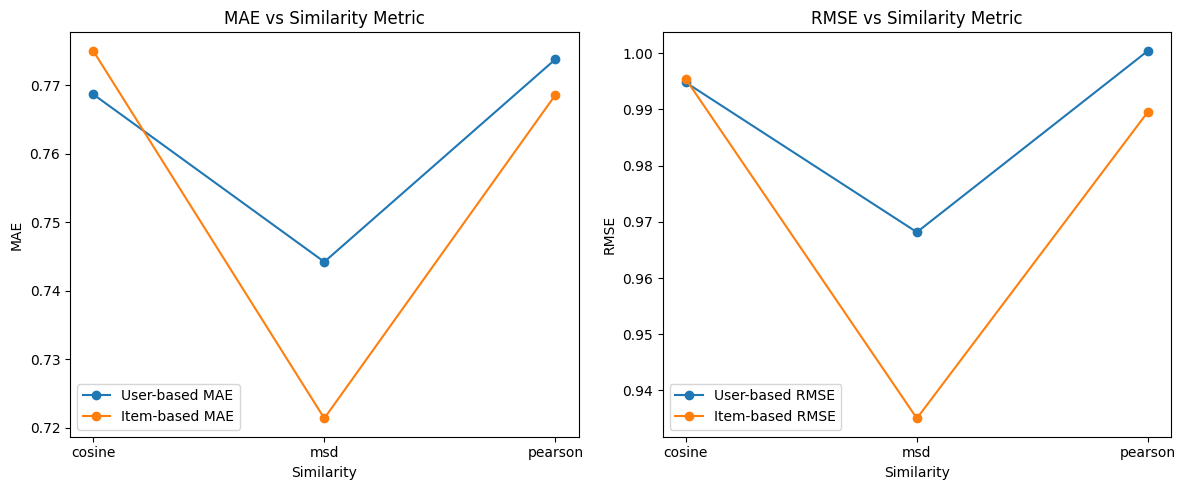


 User-based CF Performance 
cosine    MAE=0.7687   RMSE=0.9948
msd       MAE=0.7442   RMSE=0.9682
pearson   MAE=0.7738   RMSE=1.0004

 Item-based CF Performance
cosine    MAE=0.7750   RMSE=0.9954
msd       MAE=0.7213   RMSE=0.9350
pearson   MAE=0.7686   RMSE=0.9896


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, KNNBasic
from surprise.model_selection import cross_validate

# Loading ratings_small.csv
df = pd.read_csv("ratings_small.csv")

# Preparing Surprise dataset
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

def evaluate_cf(sim_name, user_based=True):
    sim_options = {
        "name": sim_name,
        "user_based": user_based
    }

    algo = KNNBasic(sim_options=sim_options)
    results = cross_validate(algo, data, measures=["MAE", "RMSE"], cv=5, verbose=False)

    mae = np.mean(results["test_mae"])
    rmse = np.mean(results["test_rmse"])
    return mae, rmse

# Evaluating all similarity metrics for User-based CF
similarities = ["cosine", "msd", "pearson"]
user_mae_list = []
user_rmse_list = []

for sim in similarities:
    mae, rmse = evaluate_cf(sim, user_based=True)
    user_mae_list.append(mae)
    user_rmse_list.append(rmse)

# Evaluating all similarity metrics for Item-based CF

item_mae_list = []
item_rmse_list = []

for sim in similarities:
    mae, rmse = evaluate_cf(sim, user_based=False)
    item_mae_list.append(mae)
    item_rmse_list.append(rmse)

# Plot results

plt.figure(figsize=(12,5))

# MAE plot
plt.subplot(1,2,1)
plt.plot(similarities, user_mae_list, marker='o', label="User-based MAE")
plt.plot(similarities, item_mae_list, marker='o', label="Item-based MAE")
plt.title("MAE vs Similarity Metric")
plt.xlabel("Similarity")
plt.ylabel("MAE")
plt.legend()

# RMSE plot
plt.subplot(1,2,2)
plt.plot(similarities, user_rmse_list, marker='o', label="User-based RMSE")
plt.plot(similarities, item_rmse_list, marker='o', label="Item-based RMSE")
plt.title("RMSE vs Similarity Metric")
plt.xlabel("Similarity")
plt.ylabel("RMSE")
plt.legend()

plt.tight_layout()
plt.show()

# Printing summary table

print("\n User-based CF Performance ")
for sim, mae, rmse in zip(similarities, user_mae_list, user_rmse_list):
    print(f"{sim:8s}  MAE={mae:.4f}   RMSE={rmse:.4f}")

print("\n Item-based CF Performance")
for sim, mae, rmse in zip(similarities, item_mae_list, item_rmse_list):
    print(f"{sim:8s}  MAE={mae:.4f}   RMSE={rmse:.4f}")


f.
Examine how the number of neighbors impacts the performances of User based
Collaborative Filtering and Item based Collaborative Filtering? Plot your results.  
(10 points)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computi

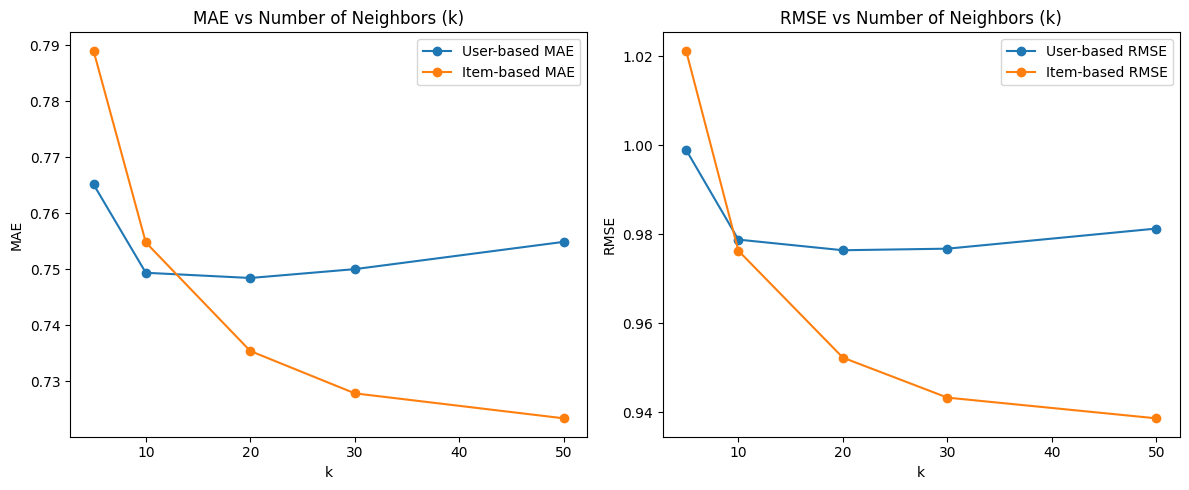


User-based CF results:
k= 5   MAE=0.7651   RMSE=0.9990
k=10   MAE=0.7493   RMSE=0.9788
k=20   MAE=0.7484   RMSE=0.9764
k=30   MAE=0.7500   RMSE=0.9768
k=50   MAE=0.7549   RMSE=0.9813

Item-based CF results:
k= 5   MAE=0.7890   RMSE=1.0213
k=10   MAE=0.7547   RMSE=0.9763
k=20   MAE=0.7354   RMSE=0.9522
k=30   MAE=0.7278   RMSE=0.9432
k=50   MAE=0.7233   RMSE=0.9386


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, KNNBasic
from surprise.model_selection import cross_validate

# Load ratings_small.csv
df = pd.read_csv("ratings_small.csv")
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

def evaluate_k(k, user_based=True):
    algo = KNNBasic(
        k=k,
        sim_options={"name": "msd", "user_based": user_based}  # use MSD (best metric from part e)
    )
    results = cross_validate(algo, data, measures=['MAE', 'RMSE'], cv=3, verbose=False)
    return np.mean(results["test_mae"]), np.mean(results["test_rmse"])


# Range of number of neighbors
k_values = [5, 10, 20, 30, 50]

user_mae = []
user_rmse = []
item_mae = []
item_rmse = []

# Evaluate user-based and item-based CF

for k in k_values:
    mae_u, rmse_u = evaluate_k(k, user_based=True)
    user_mae.append(mae_u)
    user_rmse.append(rmse_u)

    mae_i, rmse_i = evaluate_k(k, user_based=False)
    item_mae.append(mae_i)
    item_rmse.append(rmse_i)

# Plot results

plt.figure(figsize=(12,5))

# MAE plot
plt.subplot(1,2,1)
plt.plot(k_values, user_mae, marker='o', label="User-based MAE")
plt.plot(k_values, item_mae, marker='o', label="Item-based MAE")
plt.title("MAE vs Number of Neighbors (k)")
plt.xlabel("k")
plt.ylabel("MAE")
plt.legend()

# RMSE plot
plt.subplot(1,2,2)
plt.plot(k_values, user_rmse, marker='o', label="User-based RMSE")
plt.plot(k_values, item_rmse, marker='o', label="Item-based RMSE")
plt.title("RMSE vs Number of Neighbors (k)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.legend()

plt.tight_layout()
plt.show()

# Print results

print("\nUser-based CF results:")
for k, m, r in zip(k_values, user_mae, user_rmse):
    print(f"k={k:2d}   MAE={m:.4f}   RMSE={r:.4f}")

print("\nItem-based CF results:")
for k, m, r in zip(k_values, item_mae, item_rmse):
    print(f"k={k:2d}   MAE={m:.4f}   RMSE={r:.4f}")
